# Modul 3 & 5: Data Preprocessing & Visualisasi Data
Selamat datang di sistem manajemen Kafe Jamur! Tugas kita hari ini adalah mengolah data laporan bulanan kafe. Sayangnya, kasir kita kadang kurang teliti saat input data, sehingga datanya kotor (ada yang kosong, salah ketik, dan tipe datanya keliru). 

Kita akan menggunakan **Pandas** untuk membersihkan data, dan **Matplotlib** untuk menyajikannya ke dalam grafik!

### Langkah 1: Import Library dan Membaca Data
Kita akan membaca file `data_kafe.csv` menggunakan `pd.read_csv()`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Import CSV

In [2]:
df = pd.read_csv('data_kafe.csv')

# Menampilkan 5 data teratas dan informasi struktur data

In [3]:
print("--- 5 Baris Pertama Data ---")
display(df.head())

print("\n--- Informasi Tipe Data ---")
df.info()

--- 5 Baris Pertama Data ---


,Bulan,Penjualan_Kopi,Harga_Rata2,Rating,Usia_Pelanggan,Metode_Bayar
0,Jan,150.0,25000,85,22.0,QRIS
1,Feb,200.0,30000,-99,NaN,Cash
2,Mar,NaN,28000,90,25.0,QRIS
3,Apr,220.0,error,88,20.0,Kartu
4,Mei,250.0,32000,95,30.0,QRIS



--- Informasi Tipe Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Bulan           10 non-null     object 
 1   Penjualan_Kopi  9 non-null      float64
 2   Harga_Rata2     10 non-null     object 
 3   Rating          10 non-null     int64  
 4   Usia_Pelanggan  8 non-null      float64
 5   Metode_Bayar    10 non-null     object 
dtypes: float64(2), int64(1), object(3)
memory usage: 612.0+ bytes


### Langkah 2: Preprocessing - Membersihkan Data yang Kotor (Pandas)
Dari info di atas, kita punya banyak masalah:
1. **Replace:** Kolom `Rating` punya nilai aneh `-99` (tidak mungkin rating bernilai minus). Kita harus ganti ini menjadi NaN.
2. **Konversi Tipe Data Numerik:** Kolom `Harga_Rata2` terbaca sebagai Object (teks) karena ada kasir yang ngetik kata "error". Kita konversi paksa jadi angka pakai `pd.to_numeric`.
3. **Mengisi NaN (Fillna):** Kolom `Penjualan_Kopi` dan `Rating` yang kosong akan kita isi dengan nilai rata-rata (mean).
4. **Konversi Tipe Data Dasar:** Setelah diisi rata-rata (yang bentuknya desimal float), kita ubah `Penjualan_Kopi` kembali jadi bilangan bulat utuh (integer) pakai `astype()`.
5. **Menghapus NaN (Dropna):** Kalau `Usia_Pelanggan` tidak diketahui, data itu tidak berguna untuk riset target pasar kita. Kita hapus saja barisnya pakai `dropna()`.

In [4]:
# 1. Replace: Mengganti nilai -99 di Rating menjadi NaN (Not a Number)
df['Rating'] = df['Rating'].replace(-99, np.nan)

In [5]:
# 2. To Numeric: Mengubah 'Harga_Rata2' menjadi angka. errors='coerce' akan mengubah teks "error" menjadi NaN
df['Harga_Rata2'] = pd.to_numeric(df['Harga_Rata2'], errors='coerce')

# Mengecek jumlah data yang kosong (NaN)
print("--- Jumlah NaN sebelum dibersihkan ---")
print(df.isna().sum())

--- Jumlah NaN sebelum dibersihkan ---
Bulan             0
Penjualan_Kopi    1
Harga_Rata2       1
Rating            2
Usia_Pelanggan    2
Metode_Bayar      0
dtype: int64


In [6]:
# data sebelum dibersihkan
df.head()

,Bulan,Penjualan_Kopi,Harga_Rata2,Rating,Usia_Pelanggan,Metode_Bayar
0,Jan,150.0,25000.0,85.0,22.0,QRIS
1,Feb,200.0,30000.0,NaN,NaN,Cash
2,Mar,NaN,28000.0,90.0,25.0,QRIS
3,Apr,220.0,NaN,88.0,20.0,Kartu
4,Mei,250.0,32000.0,95.0,30.0,QRIS


In [7]:
# 3. Fillna: Mengisi NaN pada Kopi, Harga, dan Rating dengan rata-rata (mean)
df['Penjualan_Kopi'] = df['Penjualan_Kopi'].fillna(df['Penjualan_Kopi'].mean())
df['Harga_Rata2'] = df['Harga_Rata2'].fillna(df['Harga_Rata2'].mean())
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())

df.head()

,Bulan,Penjualan_Kopi,Harga_Rata2,Rating,Usia_Pelanggan,Metode_Bayar
0,Jan,150.000000,25000.000000,85.000,22.0,QRIS
1,Feb,200.000000,30000.000000,86.125,NaN,Cash
2,Mar,216.666667,28000.000000,90.000,25.0,QRIS
3,Apr,220.000000,30111.111111,88.000,20.0,Kartu
4,Mei,250.000000,32000.000000,95.000,30.0,QRIS


In [8]:
# 4. Astype: Mengubah tipe data float menjadi integer (bilangan bulat)
df['Penjualan_Kopi'] = df['Penjualan_Kopi'].astype(int)
df['Rating'] = df['Rating'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Bulan           10 non-null     object 
 1   Penjualan_Kopi  10 non-null     int32  
 2   Harga_Rata2     10 non-null     float64
 3   Rating          10 non-null     int32  
 4   Usia_Pelanggan  8 non-null      float64
 5   Metode_Bayar    10 non-null     object 
dtypes: float64(2), int32(2), object(2)
memory usage: 532.0+ bytes


In [9]:
# 5. Dropna: Menghapus baris yang nilai Usia_Pelanggan-nya masih NaN
# 'subset' menentukan kolom mana yang diperiksa untuk nilai kosong (NaN). 
# Jika ada baris yang memiliki NaN di kolom 'Usia_Pelanggan', maka baris tersebut akan dihapus dari DataFrame.
df = df.dropna(subset=['Usia_Pelanggan'])

print("\n--- Data Setelah Dibersihkan ---")
display(df)


--- Data Setelah Dibersihkan ---


,Bulan,Penjualan_Kopi,Harga_Rata2,Rating,Usia_Pelanggan,Metode_Bayar
0,Jan,150,25000.000000,85,22.0,QRIS
2,Mar,216,28000.000000,90,25.0,QRIS
3,Apr,220,30111.111111,88,20.0,Kartu
4,Mei,250,32000.000000,95,30.0,QRIS
5,Jun,170,27000.000000,80,28.0,Cash
6,Jul,300,35000.000000,92,24.0,QRIS
7,Aug,190,30000.000000,70,35.0,Kartu
8,Sep,210,31000.000000,86,21.0,QRIS


### Langkah 3: Visualisasi Data (Matplotlib)
Data sudah bersih! Sekarang saatnya membuat visualisasi.

 **Catatan Penting Kustomisasi Matplotlib:**
* **Warna (`color`):** 'r' (merah), 'g' (hijau), 'b' (biru), 'y' (kuning), atau kode Hex '#FF5733' (oranye).
* **Gaya Garis (`linestyle`):** '-' (solid), '--' (putus-putus), '-.' (titik garis), ':' (titik-titik).
* **Penanda (`marker`):** 'o' (lingkaran), 's' (kotak), '^' (segitiga), '*' (bintang).

#### 1. Line Plot (Grafik Garis) - Melihat Tren Penjualan
Secara default, `plt.plot()` membuat Line Plot. Sangat cocok untuk melihat tren dari waktu ke waktu.

### Kustomisasi Legend (Keterangan Grafik)
Agar grafik mudah dibaca, kita wajib menambahkan legenda (*legend*). Pada Matplotlib, kita bisa menggunakan `plt.legend()` dengan berbagai parameter untuk mempercantik tampilannya:

* **loc**: Posisi legenda. Misalnya: `'best'` (default otomatis mencari tempat paling kosong), `'upper left'`, `'lower right'`, `'center'`, dll.
* **fontsize**: Ukuran teks legenda (misalnya `10`, `12`, `'large'`, `'small'`).
* **title**: Judul khusus di dalam kotak legenda.
* **shadow**: Bernilai `True` untuk menambahkan efek bayangan 3D pada kotak legenda.
* **facecolor**: Warna latar belakang kotak legenda (misal: `'lightgray'`, `'#f9f9f9'`).
* **edgecolor**: Warna garis tepi kotak legenda.
* **ncol**: Jumlah kolom teks di dalam legenda (misalnya `2` untuk membuat legenda menyamping menjadi dua kolom).

Mari kita terapkan kustomisasi ini pada **Line Plot** (Grafik Garis) untuk melihat tren penjualan Kopi kita!

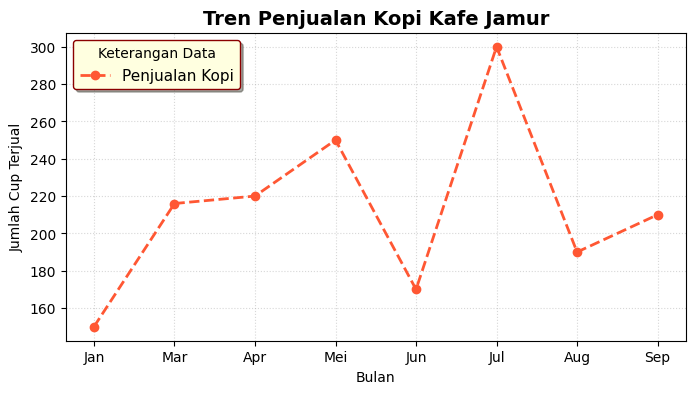

In [ ]:
# Membuat ukuran kanvas grafik
plt.figure(figsize=(8, 4))

# Membuat line plot: Sumbu X adalah Bulan, Sumbu Y adalah Penjualan Kopi
plt.plot(df['Bulan'], df['Penjualan_Kopi'], color='#FF5733', linestyle='--', marker='o', linewidth=2, label='Penjualan Kopi')

plt.title('Tren Penjualan Kopi Kafe Jamur', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Cup Terjual')
plt.grid(True, linestyle=':', alpha=0.5) 

plt.legend(
    loc='upper left',           # Posisi di kiri atas
    fontsize=11,                # Ukuran font
    title='Keterangan Data',    # Judul legend
    shadow=True,                # Ada efek bayangan
    facecolor='lightyellow',    # Latar belakang kuning muda
    edgecolor='darkred',        # Garis tepi merah tua
    ncol=1                      # Satu kolom
)

plt.show()

#### 2. Bar Plot (Grafik Batang) - Membandingkan Harga Rata-rata per Bulan
`plt.bar()` digunakan untuk membandingkan nilai antar kategori.

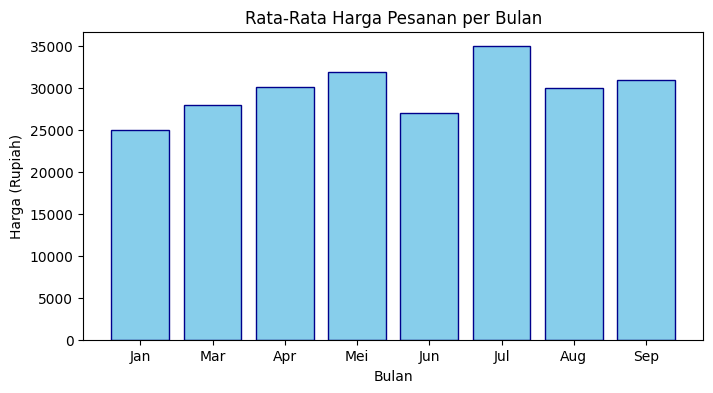

In [11]:
plt.figure(figsize=(8, 4))

# Membuat bar plot
plt.bar(df['Bulan'], df['Harga_Rata2'], color='skyblue', edgecolor='darkblue')

plt.title('Rata-Rata Harga Pesanan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Harga (Rupiah)')
plt.show()

#### 3. Scatter Plot (Grafik Titik) - Melihat Hubungan Usia & Rating
`plt.scatter()` digunakan untuk melihat apakah ada korelasi (hubungan) antara dua variabel numerik. Mari kita lihat apakah pelanggan yang lebih tua memberi rating yang lebih tinggi?

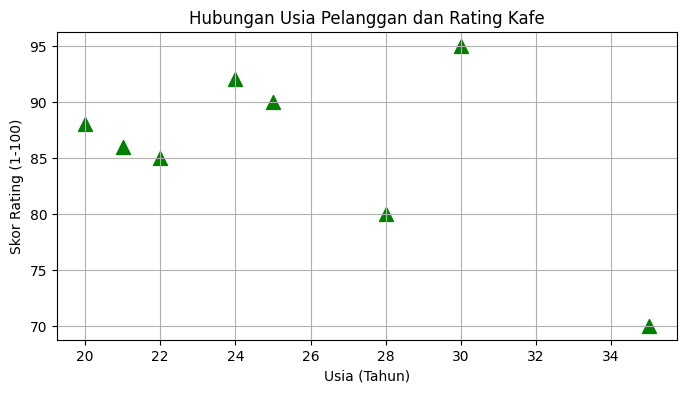

In [12]:
plt.figure(figsize=(8, 4))

# Membuat scatter plot
plt.scatter(df['Usia_Pelanggan'], df['Rating'], color='green', marker='^', s=100) # s adalah ukuran marker

plt.title('Hubungan Usia Pelanggan dan Rating Kafe')
plt.xlabel('Usia (Tahun)')
plt.ylabel('Skor Rating (1-100)')
plt.grid(True)
plt.show()

#### 4. Histogram - Melihat Distribusi Usia Pelanggan
`plt.hist()` digunakan untuk melihat frekuensi data. Rentang usia berapakah yang paling sering nongkrong di kafe ini?

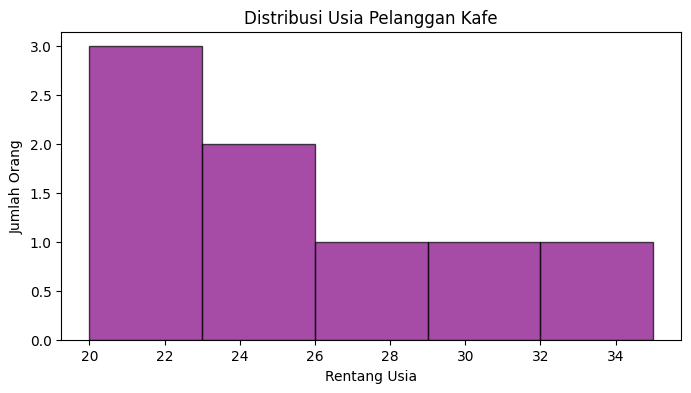

In [13]:
plt.figure(figsize=(8, 4))

# Membuat histogram, bins=5 berarti data dibagi ke dalam 5 kelompok rentang usia
plt.hist(df['Usia_Pelanggan'], bins=5, color='purple', alpha=0.7, edgecolor='black')

plt.title('Distribusi Usia Pelanggan Kafe')
plt.xlabel('Rentang Usia')
plt.ylabel('Jumlah Orang')
plt.show()

#### 5. Pie Chart (Grafik Lingkaran) - Persentase Metode Pembayaran
`plt.pie()` sangat baik untuk menunjukkan proporsi atau persentase dari keseluruhan data (100%).

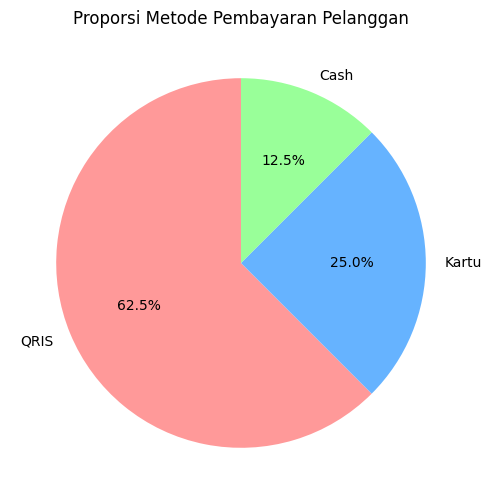

In [14]:
plt.figure(figsize=(6, 6))

# Menghitung jumlah masing-masing metode bayar dulu
metode_counts = df['Metode_Bayar'].value_counts()

# Membuat pie chart
plt.pie(metode_counts, labels=metode_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])

plt.title('Proporsi Metode Pembayaran Pelanggan')
plt.show()